# Assignment 2

This notebook is intended to produce the plots and figures for the report on Problem 1 of the practical. You should not run this notebook in Google Colab until you have finished constructing the correct solutions for transformer_solution.py and gru_solution.py

This notebook provides some limited commentary on several HuggingFace Features and toolage. You will use HuggingFace Datasets to load the Yelp Polarity dataset for sentiment analysis. The notebook will define a Bert tokenizer, collate functions, and then train and evaluate several models using the HuggingFace utilities mentioned above. Remember, the most crucial part here is running the experiments for the report.

In [43]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Mount your Google Drive

In [44]:
# If you run this notebook locally or on a cluster (i.e. not on Google Colab)
# you can delete this cell which is specific to Google Colab. You may also
# change the paths for data/logs in Arguments below.


# from google.colab import drive
# drive.mount('/content/gdrive')

# !pip install -qqq datasets transformers textattack --upgrade

### Link your assignment folder & install requirements
Enter the path to the assignment folder in your Google Drive
If you run this notebook locally or on a cluster (i.e. not on Google Colab)
you can delete this cell which is specific to Google Colab. 

In [45]:
import sys
import os
import shutil
import warnings

folder = "" #@param {type:"string"}
!ln -Ts "$folder" /content/assignment 2> /dev/null
!cp gdrive/MyDrive/Assignment2/transformer_solution.py .
!cp gdrive/MyDrive/Assignment2/gru_solution.py .

# Add the assignment folder to Python path
# if '/content/assignment' not in sys.path:
#   sys.path.insert(0, '/content/assignment')

# Check if CUDA is available
import torch
if not torch.cuda.is_available():
  warnings.warn('CUDA is not available.')

The system cannot find the path specified.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'cp' is not recognized as an internal or external command,
operable program or batch file.


### Running on GPU
For this assignment, it will be necessary to run your experiments on GPU. To make sure the notebook is running on GPU, you can change the notebook settings with
* (EN) `Edit > Notebook Settings`
* (FR) `Modifier > Paramètres du notebook`


In [46]:
import matplotlib.pyplot as plt
import urllib.request
import time
import os
import json
import random
from typing import List, Dict, Union, Optional, Tuple

from sklearn.metrics import f1_score
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Optimizer, AdamW

from dataclasses import dataclass
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from datasets import Dataset, load_dataset, concatenate_datasets
from transformers import AutoModel, AutoTokenizer
from tokenizers import Tokenizer

from transformer_solution import Transformer, MultiHeadedAttention
from gru_solution import EncoderDecoder

In [47]:
def set_seed(seed: int = 0, device: torch.device = None):
    random.seed(seed)
    np.random.seed(seed)
    rng = np.random.default_rng(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if device is not None and device.type == "cuda":
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    return rng

In [48]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--> Device selected: {device}")
rng = set_seed(seed=0, device=device)

--> Device selected: cuda


In [49]:
dataset_name = "yelp_polarity"
dataset_train_original = load_dataset(dataset_name, split="train", cache_dir="assignment/data")
dataset_test_original = load_dataset(dataset_name, split="test", cache_dir="assignment/data").shuffle(generator=rng)
dataset_test = dataset_test_original.select(range(1000))
dataset_train = concatenate_datasets([
    dataset_train_original,
    dataset_test_original.select(range(1000, len(dataset_test_original)))
])
print(f"{len(dataset_train)=}, {len(dataset_test)=}")

len(dataset_train)=597000, len(dataset_test)=1000


### 🔍 Quick look at the data
Lets have quick look at a few samples in our test set.

In [50]:
n_samples_to_see = 3
for i in range(n_samples_to_see):
  print("-"*30)
  print("title:", dataset_test[i]["text"])
  print("label:", dataset_test[i]["label"])

------------------------------
title: Best sweet potato fries I've ever had. Ever. \n\nJust the right amount of crispy with salt and sugar sprinkled on it and an addictive sweet sauce for dipping. Seriously these things were so good I went back the next night and ordered some to go after having a few drinks. \n\nI honestly don't even remember what my burger tasted like, but if you're staying at/near the Wynn definitely cross the street and check this place out.
label: 1
------------------------------
title: OK, next time I'm just trying the drinks.\n\nI didn't come here to drink, I came here for a nice date on a Friday night.  First off, I don't think you should introduce the night's specials by coming to the table 15 minutes after we have been seated and say \""have you guys seen this?\""  Oh, guess those are the specials.  Then we had to ask what the fish of the day was.  Needless to say, the service failed the place before anything was consumed.\n\nThe options on the menu were inter

### 1️. Tokenize the `text`
Tokenize the `text`portion of each sample (i.e. parsing the text to smaller chunks). Tokenization can happen in many ways; traditionally, this was done based on the white spaces. With transformer-based models, tokenization is performed based on the frequency of occurrence of "chunk of text". This frequency can be learned in many different ways. However the most common one is the [**wordpiece**](https://arxiv.org/pdf/1609.08144v2.pdf) model. 
> The wordpiece model is generated using a data-driven approach to maximize the language-model likelihood
of the training data, given an evolving word definition. Given a training corpus and a number of desired
tokens $D$, the optimization problem is to select $D$ wordpieces such that the resulting corpus is minimal in the
number of wordpieces when segmented according to the chosen wordpiece model.

Under this model:
1. Not all things can be converted to tokens depending on the model. For example, most models have been pretrained without any knowledge of emojis. So their token will be `[UNK]`, which stands for unknown.
2. Some words will be mapped to multiple tokens!
3. Depending on the kind of model, your tokens may or may not respect capitalization

In [51]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [52]:
input_sample = "Welcome to IFT6135. We now teach you 🤗(HUGGING FACE) Library :DDD."
tokenizer.tokenize(input_sample)

['welcome',
 'to',
 'if',
 '##t',
 '##6',
 '##13',
 '##5',
 '.',
 'we',
 'now',
 'teach',
 'you',
 '[UNK]',
 '(',
 'hugging',
 'face',
 ')',
 'library',
 ':',
 'dd',
 '##d',
 '.']

### 2. Encoding
Once we have tokenized the text, we then need to convert these chuncks to numbers so we can feed them to our model. This conversion is basically a look-up in a dictionary **from `str` $\to$ `int`**. The tokenizer object can also perform this work. While it does so it will also add the *special* tokens needed by the model to the encodings. 

In [53]:
input_sample = "Welcome to IFT6135. We now teach you 🤗(HUGGING FACE) Library :DDD." #@param {type: "string"}

print("--> Token Encodings:\n",tokenizer.encode(input_sample))
print("-."*15)
print("--> Token Encodings Decoded:\n",tokenizer.decode(tokenizer.encode(input_sample)))

--> Token Encodings:
 [101, 6160, 2000, 2065, 2102, 2575, 17134, 2629, 1012, 2057, 2085, 6570, 2017, 100, 1006, 17662, 2227, 1007, 3075, 1024, 20315, 2094, 1012, 102]
-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
--> Token Encodings Decoded:
 [CLS] welcome to ift6135. we now teach you [UNK] ( hugging face ) library : ddd. [SEP]


### 3️. Truncate/Pad samples
Since all the sample in the batch will not have the same sequence length, we would need to truncate the longer sequences (i.e. the ones that exeed a predefined maximum length) and pad the shorter ones so we that we can equal length for all the samples in the batch. Once this is achieved, we would need to convert the result to `torch.Tensor`s and return. These tensors will then be retrieved from the [dataloader](https://https//pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [54]:
class Collate:
    def __init__(self, model_name: str, max_len: int) -> None:
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.max_len = max_len
        self.text_column = "text"
        self.label_column = "label"

    def __call__(self, batch: List[Dict[str, Union[str, int]]]) -> Dict[str, torch.Tensor]:
        texts = list(map(lambda batch_instance: batch_instance[self.text_column], batch))
        tokenized_inputs = self.tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
            return_token_type_ids=False,
        )

        labels = list(map(lambda batch_instance: int(batch_instance[self.label_column]), batch))
        labels = torch.LongTensor(labels)
        return dict(tokenized_inputs, **{"labels": labels})


#### 🧑‍🍳 Setting up the collate function

In [55]:
model_name = "bert-base-uncased"
sample_max_length = 256         #@param {type: "integer"}
collate = Collate(model_name=model_name, max_len=sample_max_length)

### 4. Models

In [56]:
class ReviewClassifierPretrained(nn.Module):
    def __init__(
        self,
        backbone: str = "bert-base-uncased",
        backbone_hidden_size: int = 768,
        num_classes: int = 2,
        device: torch.device = torch.device("cpu"),
    ):
        super().__init__()
        self.backbone = backbone
        self.backbone_hidden_size = backbone_hidden_size
        self.num_classes = num_classes
        self.device = device
        self.back_bone = AutoModel.from_pretrained(
            self.backbone,
            output_attentions=False,
            output_hidden_states=False,
        )
        for parameter in self.back_bone.parameters():
            parameter.requires_grad= False
        self.classifier = torch.nn.Linear(self.backbone_hidden_size, self.num_classes)
        self.loss_fn = torch.nn.CrossEntropyLoss()


    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        with torch.no_grad():
            self.back_bone.eval()
            back_bone_output = self.back_bone(input_ids.to(self.device), attention_mask=attention_mask.to(self.device))
        hidden_states = back_bone_output[0]
        pooled_output = hidden_states[:, 0]  # getting the [CLS] token
        logits = self.classifier(pooled_output)
        loss = self.loss_fn(
            logits.view(-1, self.num_classes),
            labels.view(-1).to(self.device),
        )
        return loss, logits


class ReviewClassifierRNN(nn.Module):
    def __init__(
        self,
        num_classes: int = 2,
        vocabulary_size: int = 30522,
        encoder_only: bool = False,
        dropout: float = 0.5,
        embed_dim: int = 256,
        with_attn: bool = True,
        device: torch.device = torch.device("cpu"),
    ):
        super().__init__()
        self.num_classes = num_classes
        self.encoder_only = encoder_only
        self.device = device
        self.back_bone = EncoderDecoder(
            vocabulary_size=vocabulary_size,
            dropout=dropout,
            encoder_only=encoder_only,
            with_attn=with_attn,
        )
        self.classifier = torch.nn.Linear(embed_dim, self.num_classes)
        self.loss_fn = torch.nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        pooled_output, _ = self.back_bone(input_ids.to(self.device), attention_mask.to(self.device))
        logits = self.classifier(pooled_output)
        loss = self.loss_fn(
            logits.view(-1, self.num_classes),
            labels.view(-1).to(self.device),
        )
        return loss, logits


class ReviewClassifierTransformer(nn.Module):
    def __init__(
        self,
        num_classes: int = 2,
        vocabulary_size: int = 30522,
        sequence_length: int = 256,
        num_heads: int = 4,
        num_layers: int = 4,
        block: str="prenorm",
        embed_dim: int = 256,
        hidden_dim: int = 256,
        dropout: float = 0.3,
        device: torch.device = torch.device("cpu"),
    ):
        super().__init__()
        self.num_classes = num_classes
        self.device = device
        self.back_bone = Transformer(
            vocabulary_size=vocabulary_size,
            sequence_length=sequence_length,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            num_layers=num_layers,
            block=block,
            dropout=dropout,
        )
        self.classifier = torch.nn.Linear(embed_dim, self.num_classes)
        self.loss_fn = torch.nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        pooled_output = self.back_bone(input_ids.to(self.device), attention_mask.to(self.device))
        logits = self.classifier(pooled_output)
        loss = self.loss_fn(
            logits.view(-1, self.num_classes),
            labels.view(-1).to(self.device),
        )
        return loss, logits


### 5. Trainer

In [57]:
def train_one_epoch(
    model: torch.nn.Module,
    train_dataloader: DataLoader,
    test_dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    logging_frequency: int,
    logs: dict,
    device: torch.device,
    epoch_idx: int = 0,
):
    model.train()
    epoch_loss = 0
    logging_loss = 0
    epoch_start_time = time.time()
    logfreq_start_time = time.time()
    num_train_batch = len(train_dataloader)
    for step, batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        loss, _ = model(**batch)
        loss.backward()
        optimizer.step()
        current_lr = optimizer.param_groups[0]["lr"]
        # print(f"{step=}, {current_lr=}")

        epoch_loss += loss.item()
        logging_loss += loss.item()

        if (step + 1) % logging_frequency == 0 or (step + 1) == num_train_batch:
            logfreq_time = time.time() - logfreq_start_time
            logs["train_time_accum"].append(logfreq_time + logs["train_time_accum"][-1])
            logs["train_loss_logfreq"].append(logging_loss / logging_frequency)
            (
                eval_acc,
                tp_rate,
                fp_rate,
                tn_rate,
                fn_rate,
                f1,
                eval_loss,
                eval_time,
            ) = evaluate(model=model, test_dataloader=test_dataloader, device=device)
            logs["eval_acc_logfreq"].append(eval_acc)
            logs["eval_tp_rate_logfreq"].append(tp_rate)
            logs["eval_fp_rate_logfreq"].append(fp_rate)
            logs["eval_tn_rate_logfreq"].append(tn_rate)
            logs["eval_fn_rate_logfreq"].append(fn_rate)
            logs["eval_f1_score_logfreq"].append(f1)
            logs["eval_loss_logfreq"].append(eval_loss)
            logs["eval_time_accum"].append(eval_time + logs["eval_time_accum"][-1])
            print(
                f"Epoch {epoch_idx+1} step {step+1}/{num_train_batch}: "
                f"train time {logs["train_time_accum"][-1]:.1f} seconds, "
                f"train loss {logs["train_loss_logfreq"][-1]:.3f}, "
                f"eval time {eval_time:.1f}, eval loss {eval_loss:.3f}, eval acc {eval_acc:.3f}, "
                f"eval tp rate {tp_rate:.3f}, eval fp rate {fp_rate:.3f}, eval tn rate {tn_rate:.3f}, eval fn rate {fn_rate:.3f}, eval f1 score {f1:.3f}, "
                f"lr {current_lr:.3e}")

            logging_loss = 0
            logfreq_start_time = time.time()

            if (step + 1) == num_train_batch:
                logs["eval_loss_epoch"].append(eval_loss)
                logs["eval_time_epoch"].append(eval_time)
                logs["eval_acc_epoch"].append(eval_acc)

    train_loss_epoch = epoch_loss / num_train_batch
    train_time_epoch = time.time() - epoch_start_time
    logs["train_loss_epoch"].append(train_loss_epoch)
    logs["train_time_epoch"].append(train_time_epoch)
    print(f"Epoch {epoch_idx+1}: train time epoch: {train_time_epoch:.1f}, train loss epoch mean: {train_loss_epoch:.3f}")


In [58]:
def evaluate(
    model: torch.nn.Module,
    test_dataloader: DataLoader,
    device: torch.device,
):
    model.eval()
    eval_loss = 0
    y_pred = []
    y_true = []
    start_time = time.time()
    with torch.no_grad():
        for step, batch in enumerate(test_dataloader):
            loss, logits = model(**batch)
            eval_loss += loss.item()
            predictions = np.argmax(logits.detach().cpu().numpy(), axis=1)
            y_pred.extend(predictions)
            y_true.extend(batch["labels"].cpu().numpy())
    y_pred, y_true = np.array(y_pred, dtype=np.float32), np.array(y_true, dtype=np.float32)
    # print(f"{sum(y_true==1)=}, {sum(y_true==0)=}")
    accuracy = np.sum(y_pred == y_true) / len(y_true)
    tp_rate = np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1)
    fp_rate = np.sum((y_true == 0) & (y_pred == 1)) / np.sum(y_true == 0)
    tn_rate = np.sum((y_true == 0) & (y_pred == 0)) / np.sum(y_true == 0)
    fn_rate = np.sum((y_true == 1) & (y_pred == 0)) / np.sum(y_true == 1)
    f1 = f1_score(y_true=y_true, y_pred=y_pred)
    eval_loss = eval_loss / len(test_dataloader)
    model.train()
    return (
        accuracy,
        tp_rate,
        fp_rate,
        tn_rate,
        fn_rate,
        f1,
        eval_loss,
        time.time() - start_time
    )


In [59]:
def reset_logs(model):
    logs = dict()
    logs["parameters"] = sum([p.numel() for p in model.parameters() if p.requires_grad])
    print(f"Number of parameters: {logs['parameters']}")

    logs["train_time_accum"] = [0]
    logs["train_loss_logfreq"] = []
    logs["train_loss_epoch"] = []
    logs["train_time_epoch"] = []

    logs["eval_time_accum"] = [0]
    logs["eval_acc_logfreq"] = []
    logs["eval_tp_rate_logfreq"] = []
    logs["eval_fp_rate_logfreq"] = []
    logs["eval_tn_rate_logfreq"] = []
    logs["eval_fn_rate_logfreq"] = []
    logs["eval_f1_score_logfreq"] = []
    logs["eval_loss_logfreq"] = []
    logs["eval_loss_epoch"] = []
    logs["eval_time_epoch"] = []
    logs["eval_acc_epoch"] = []
    return logs


def save_logs(dictionary, log_dir, exp_id):
    log_dir = os.path.join(log_dir, exp_id)
    os.makedirs(log_dir, exist_ok=True)
    # Log arguments
    with open(os.path.join(log_dir, "args.json"), "w") as f:
      json.dump(dictionary, f, indent=2)

def save_model(model, log_dir, exp_id):
  log_dir = os.path.join(log_dir, exp_id)
  os.makedirs(log_dir, exist_ok=True)
  # Save model
  torch.save(model.state_dict(), f"assignment/models/model_{exp_id}.pt")


### 6. Problem 2
Feel free to modify this code however it is convenient for you to produce a report except for the model parameters.

In [60]:
TEST_MODE = False  # Set to False for full training

batch_size = 512
logging_frequency = 25
learning_rate = 1e-4
sample_max_length = 256
num_epochs = 5

if TEST_MODE:
    num_epochs = 1
    logging_frequency = 1
    dataset_train_small = dataset_train.select(range(5120))
    dataset_test_small = dataset_test.select(range(128))
    train_dataloader = DataLoader(dataset_train_small, batch_size=batch_size, shuffle=True, collate_fn=collate)
    test_dataloader = DataLoader(dataset_test_small, batch_size=batch_size, shuffle=False, collate_fn=collate)
    print(f"TEST MODE: {len(dataset_train_small)} train ({len(train_dataloader)} batches), {len(dataset_test_small)} test, {num_epochs} epoch(s)")
else:
    train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, collate_fn=collate)
    test_dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, collate_fn=collate)
    print(f"FULL MODE: {len(dataset_train)} train, {len(dataset_test)} test, {num_epochs} epoch(s)")

FULL MODE: 597000 train, 1000 test, 5 epoch(s)


In [61]:
all_logs = {}

for experimental_setting in range(1, 9):
    if TEST_MODE:
        num_epochs_run = 1
    else:
        num_epochs_run = 2 if experimental_setting == 8 else num_epochs

    if experimental_setting == 1:
        desc = "GRU: no dropout, encoder only"
        model = ReviewClassifierRNN(dropout=0.0, encoder_only=True, device=device)
    elif experimental_setting == 2:
        desc = "GRU: dropout, encoder only"
        model = ReviewClassifierRNN(dropout=0.3, encoder_only=True, device=device)
    elif experimental_setting == 3:
        desc = "GRU: dropout, encoder-decoder, no attn"
        model = ReviewClassifierRNN(dropout=0.3, encoder_only=False, with_attn=False, device=device)
    elif experimental_setting == 4:
        desc = "GRU: dropout, encoder-decoder, with attn"
        model = ReviewClassifierRNN(dropout=0.3, encoder_only=False, with_attn=True, device=device)
    elif experimental_setting == 5:
        desc = "Transformer: 2 layers, prenorm"
        model = ReviewClassifierTransformer(sequence_length=sample_max_length, num_heads=4, num_layers=2, block="prenorm", dropout=0.3, device=device)
    elif experimental_setting == 6:
        desc = "Transformer: 4 layers, prenorm"
        model = ReviewClassifierTransformer(sequence_length=sample_max_length, num_heads=4, num_layers=4, block="prenorm", dropout=0.3, device=device)
    elif experimental_setting == 7:
        desc = "Transformer: 2 layers, postnorm"
        model = ReviewClassifierTransformer(sequence_length=sample_max_length, num_heads=4, num_layers=2, block="postnorm", dropout=0.3, device=device)
    elif experimental_setting == 8:
        desc = "Pretrained BERT"
        model = ReviewClassifierPretrained(backbone=model_name, device=device)

    print(f"\n{'='*60}")
    print(f"Experiment {experimental_setting}: {desc}")
    print(f"{'='*60}")

    model.to(device)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    logs = reset_logs(model)
    logs["description"] = desc

    # Reset GPU memory stats for Q8 tracking
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    for epoch in range(num_epochs_run):
        train_one_epoch(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=test_dataloader,
            optimizer=optimizer,
            logging_frequency=logging_frequency,
            logs=logs,
            device=device,
            epoch_idx=epoch,
        )

    # Record peak GPU memory for Q8
    if device.type == "cuda":
        logs["gpu_peak_memory_mb"] = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        print(f"Peak GPU memory: {logs['gpu_peak_memory_mb']:.1f} MB")
    else:
        logs["gpu_peak_memory_mb"] = None

    save_logs(logs, "assignment/log", str(experimental_setting))
    all_logs[experimental_setting] = logs
    del model
    torch.cuda.empty_cache()


Experiment 1: GRU: no dropout, encoder only
Number of parameters: 8603650
Epoch 1 step 25/1167: train time 4.2 seconds, train loss 0.688, eval time 0.2, eval loss 0.676, eval acc 0.572, eval tp rate 0.388, eval fp rate 0.266, eval tn rate 0.734, eval fn rate 0.612, eval f1 score 0.458, lr 1.000e-04
Epoch 1 step 50/1167: train time 8.0 seconds, train loss 0.670, eval time 0.2, eval loss 0.665, eval acc 0.601, eval tp rate 0.726, eval fp rate 0.508, eval tn rate 0.492, eval fn rate 0.274, eval f1 score 0.630, lr 1.000e-04
Epoch 1 step 75/1167: train time 11.8 seconds, train loss 0.652, eval time 0.2, eval loss 0.645, eval acc 0.624, eval tp rate 0.610, eval fp rate 0.364, eval tn rate 0.636, eval fn rate 0.390, eval f1 score 0.603, lr 1.000e-04
Epoch 1 step 100/1167: train time 15.7 seconds, train loss 0.633, eval time 0.2, eval loss 0.627, eval acc 0.649, eval tp rate 0.638, eval fp rate 0.341, eval tn rate 0.659, eval fn rate 0.362, eval f1 score 0.629, lr 1.000e-04
Epoch 1 step 125/1

c:\Users\guill\GitHub\IFT6135-Assignments\assignment-2\venv\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch 1 step 25/1167: train time 4.0 seconds, train loss 0.691, eval time 0.2, eval loss 0.685, eval acc 0.540, eval tp rate 0.812, eval fp rate 0.698, eval tn rate 0.302, eval fn rate 0.188, eval f1 score 0.622, lr 1.000e-04
Epoch 1 step 50/1167: train time 7.8 seconds, train loss 0.678, eval time 0.2, eval loss 0.666, eval acc 0.596, eval tp rate 0.593, eval fp rate 0.402, eval tn rate 0.598, eval fn rate 0.407, eval f1 score 0.578, lr 1.000e-04
Epoch 1 step 75/1167: train time 11.6 seconds, train loss 0.663, eval time 0.2, eval loss 0.655, eval acc 0.602, eval tp rate 0.675, eval fp rate 0.462, eval tn rate 0.538, eval fn rate 0.325, eval f1 score 0.613, lr 1.000e-04
Epoch 1 step 100/1167: train time 15.4 seconds, train loss 0.649, eval time 0.2, eval loss 0.637, eval acc 0.636, eval tp rate 0.527, eval fp rate 0.268, eval tn rate 0.732, eval fn rate 0.473, eval f1 score 0.575, lr 1.000e-04
Epoch 1 step 125/1167: train time 19.3 seconds, train loss 0.639, eval time 0.2, eval loss 0.

c:\Users\guill\GitHub\IFT6135-Assignments\assignment-2\venv\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch 1 step 25/1167: train time 5.3 seconds, train loss 0.689, eval time 0.2, eval loss 0.682, eval acc 0.544, eval tp rate 0.642, eval fp rate 0.542, eval tn rate 0.458, eval fn rate 0.358, eval f1 score 0.568, lr 1.000e-04
Epoch 1 step 50/1167: train time 10.4 seconds, train loss 0.675, eval time 0.2, eval loss 0.668, eval acc 0.587, eval tp rate 0.550, eval fp rate 0.381, eval tn rate 0.619, eval fn rate 0.450, eval f1 score 0.554, lr 1.000e-04
Epoch 1 step 75/1167: train time 15.5 seconds, train loss 0.663, eval time 0.2, eval loss 0.656, eval acc 0.605, eval tp rate 0.730, eval fp rate 0.505, eval tn rate 0.495, eval fn rate 0.270, eval f1 score 0.633, lr 1.000e-04
Epoch 1 step 100/1167: train time 20.6 seconds, train loss 0.648, eval time 0.3, eval loss 0.631, eval acc 0.636, eval tp rate 0.625, eval fp rate 0.355, eval tn rate 0.645, eval fn rate 0.375, eval f1 score 0.616, lr 1.000e-04
Epoch 1 step 125/1167: train time 25.7 seconds, train loss 0.638, eval time 0.2, eval loss 0

c:\Users\guill\GitHub\IFT6135-Assignments\assignment-2\venv\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch 1 step 25/1167: train time 6.0 seconds, train loss 0.686, eval time 0.2, eval loss 0.681, eval acc 0.565, eval tp rate 0.745, eval fp rate 0.593, eval tn rate 0.407, eval fn rate 0.255, eval f1 score 0.615, lr 1.000e-04
Epoch 1 step 50/1167: train time 11.7 seconds, train loss 0.675, eval time 0.2, eval loss 0.668, eval acc 0.600, eval tp rate 0.520, eval fp rate 0.330, eval tn rate 0.670, eval fn rate 0.480, eval f1 score 0.549, lr 1.000e-04
Epoch 1 step 75/1167: train time 17.4 seconds, train loss 0.660, eval time 0.2, eval loss 0.651, eval acc 0.599, eval tp rate 0.664, eval fp rate 0.458, eval tn rate 0.542, eval fn rate 0.336, eval f1 score 0.607, lr 1.000e-04
Epoch 1 step 100/1167: train time 23.2 seconds, train loss 0.645, eval time 0.2, eval loss 0.629, eval acc 0.614, eval tp rate 0.707, eval fp rate 0.467, eval tn rate 0.533, eval fn rate 0.293, eval f1 score 0.631, lr 1.000e-04
Epoch 1 step 125/1167: train time 28.9 seconds, train loss 0.628, eval time 0.2, eval loss 0

Loading weights: 100%|██████████| 199/199 [00:00<?, ?it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Experiment 8: Pretrained BERT
Number of parameters: 1538
Epoch 1 step 25/1167: train time 103.1 seconds, train loss 0.706, eval time 8.0, eval loss 0.681, eval acc 0.589, eval tp rate 0.563, eval fp rate 0.388, eval tn rate 0.612, eval fn rate 0.437, eval f1 score 0.561, lr 1.000e-04
Epoch 1 step 50/1167: train time 206.4 seconds, train loss 0.661, eval time 8.1, eval loss 0.638, eval acc 0.746, eval tp rate 0.707, eval fp rate 0.220, eval tn rate 0.780, eval fn rate 0.293, eval f1 score 0.722, lr 1.000e-04
Epoch 1 step 75/1167: train time 309.5 seconds, train loss 0.623, eval time 8.0, eval loss 0.602, eval acc 0.802, eval tp rate 0.827, eval fp rate 0.220, eval tn rate 0.780, eval fn rate 0.173, eval f1 score 0.796, lr 1.000e-04
Epoch 1 step 100/1167: train time 412.7 seconds, train loss 0.589, eval time 8.1, eval loss 0.569, eval acc 0.840, eval tp rate 0.809, eval fp rate 0.133, eval tn rate 0.867, eval fn rate 0.191, eval f1 score 0.825, lr 1.000e-04
Epoch 1 step 125/1167: train 

### Q1: Learning Curves
Plot train loss, validation loss, and validation accuracy over training iterations for all 8 experiments.

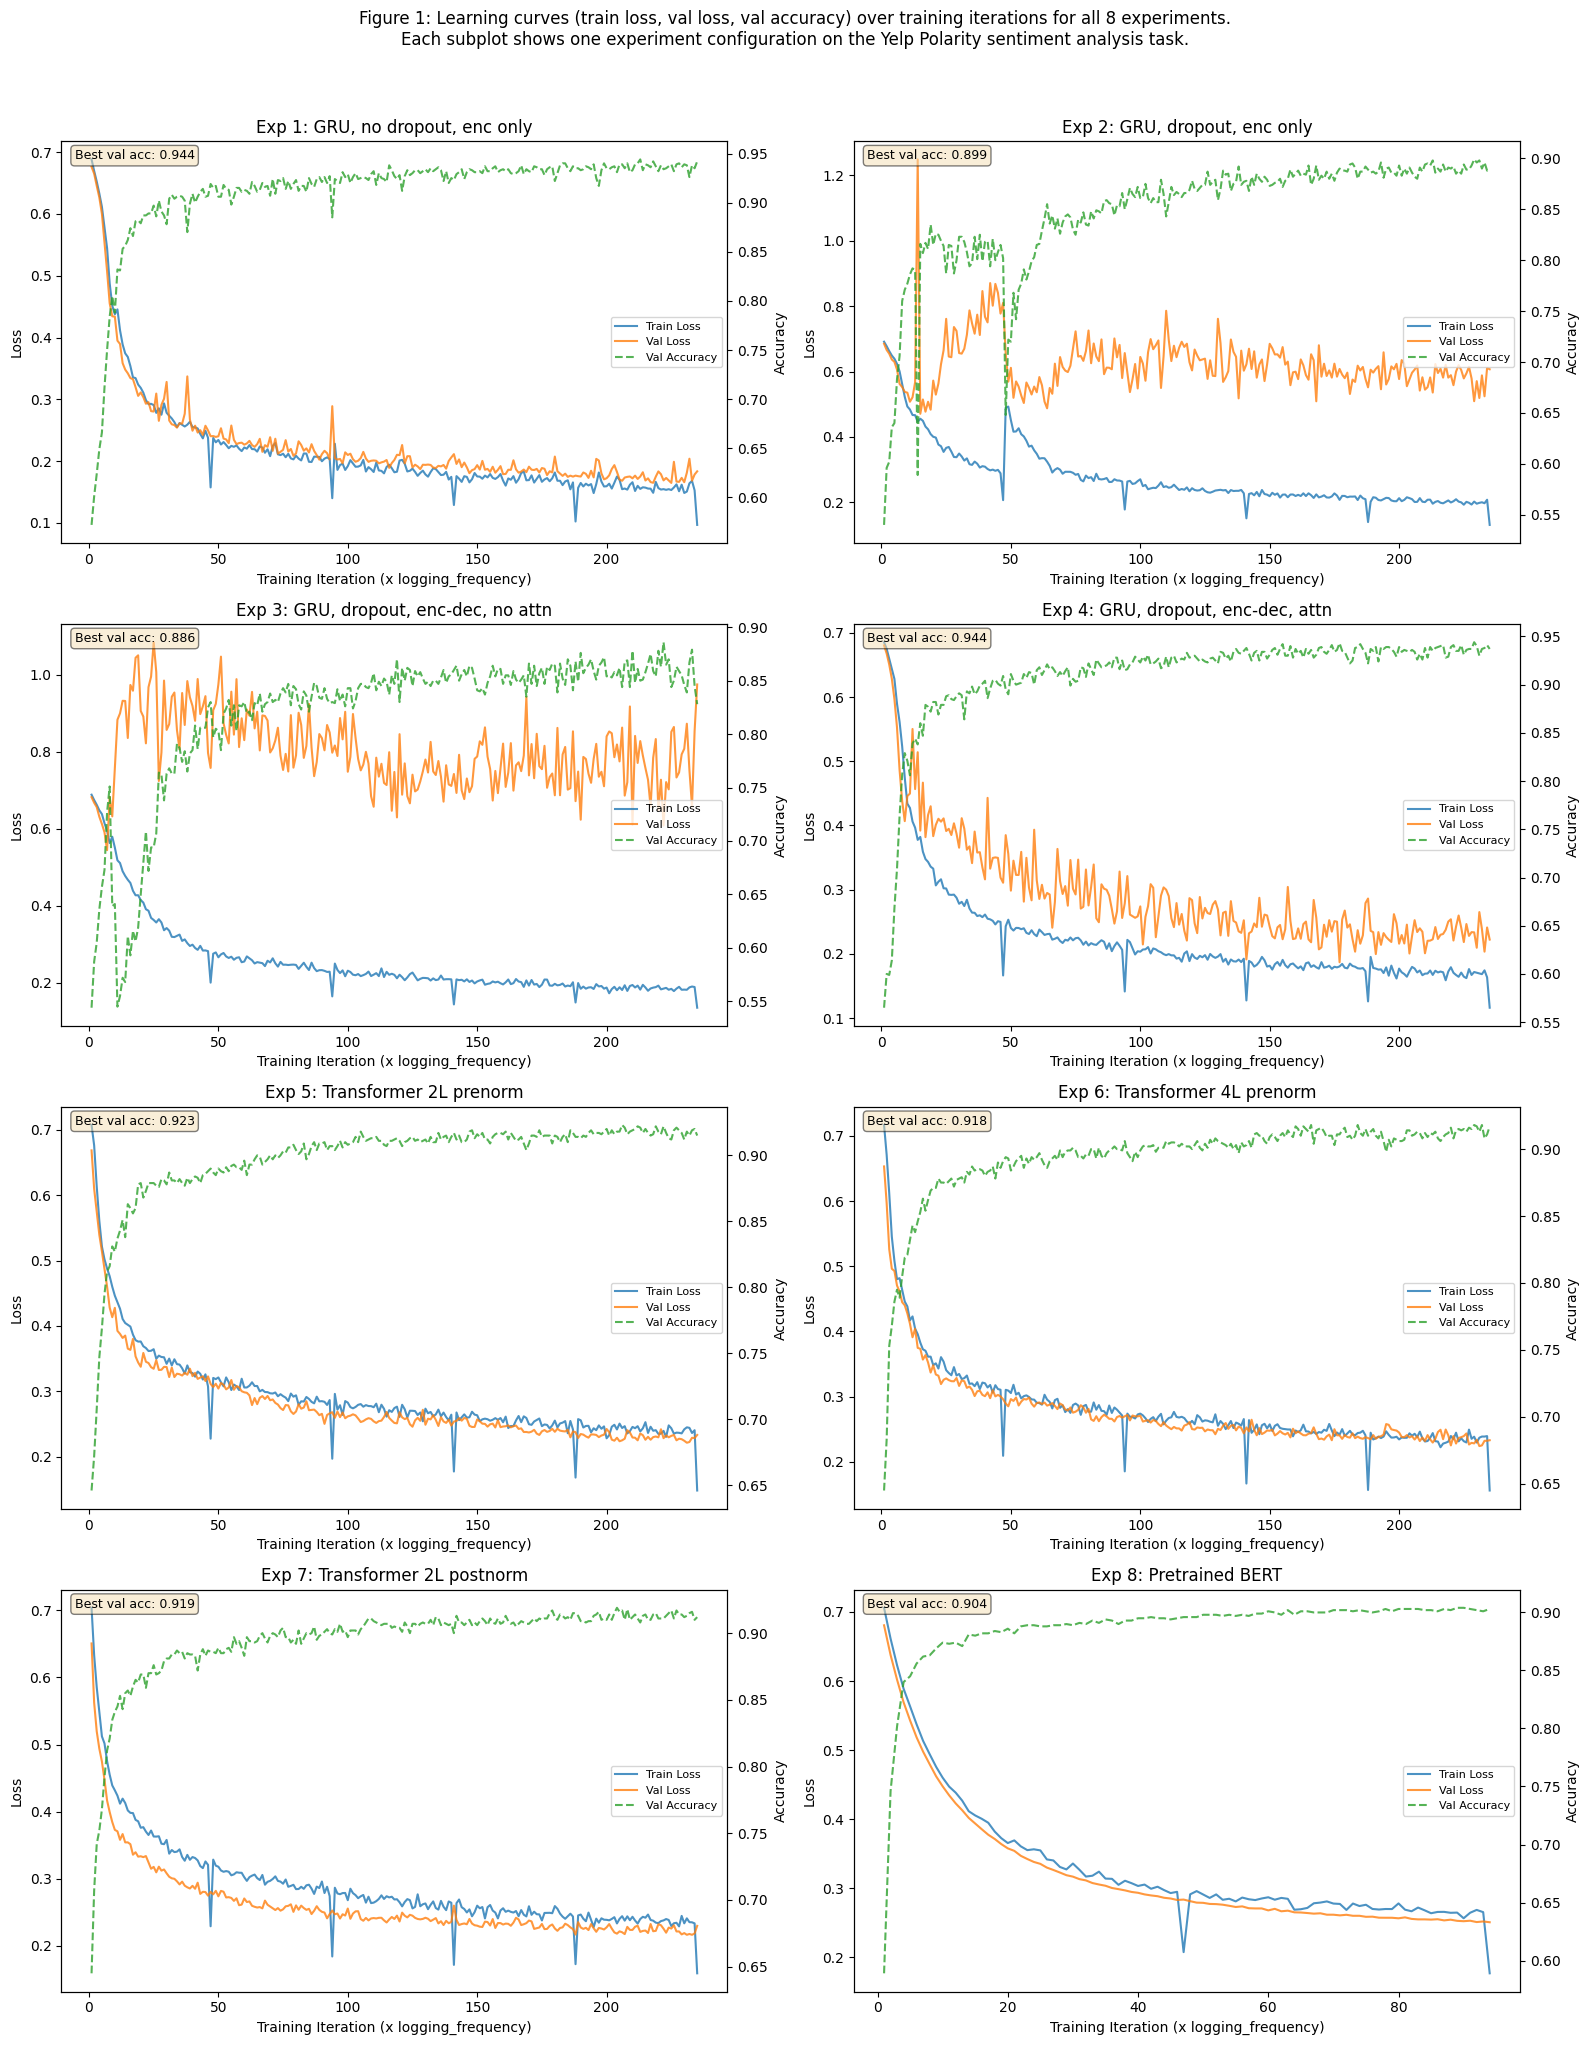


Best validation accuracy per experiment:
  Exp 1: GRU, no dropout, enc only: 0.9440
  Exp 2: GRU, dropout, enc only: 0.8990
  Exp 3: GRU, dropout, enc-dec, no attn: 0.8860
  Exp 4: GRU, dropout, enc-dec, attn: 0.9440
  Exp 5: Transformer 2L prenorm: 0.9230
  Exp 6: Transformer 4L prenorm: 0.9180
  Exp 7: Transformer 2L postnorm: 0.9190
  Exp 8: Pretrained BERT: 0.9040


In [62]:
experiment_names = {
    1: "Exp 1: GRU, no dropout, enc only",
    2: "Exp 2: GRU, dropout, enc only",
    3: "Exp 3: GRU, dropout, enc-dec, no attn",
    4: "Exp 4: GRU, dropout, enc-dec, attn",
    5: "Exp 5: Transformer 2L prenorm",
    6: "Exp 6: Transformer 4L prenorm",
    7: "Exp 7: Transformer 2L postnorm",
    8: "Exp 8: Pretrained BERT",
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for exp_id in range(1, 9):
    ax = axes[exp_id - 1]
    logs = all_logs[exp_id]
    iterations = list(range(1, len(logs["train_loss_logfreq"]) + 1))

    ax_loss = ax
    ax_acc = ax.twinx()

    ax_loss.plot(iterations, logs["train_loss_logfreq"], label="Train Loss", color="tab:blue", alpha=0.8)
    ax_loss.plot(iterations, logs["eval_loss_logfreq"], label="Val Loss", color="tab:orange", alpha=0.8)
    ax_acc.plot(iterations, logs["eval_acc_logfreq"], label="Val Accuracy", color="tab:green", linestyle="--", alpha=0.8)

    ax_loss.set_xlabel("Training Iteration (x logging_frequency)")
    ax_loss.set_ylabel("Loss")
    ax_acc.set_ylabel("Accuracy")
    ax_loss.set_title(experiment_names[exp_id])

    # Combine legends
    lines1, labels1 = ax_loss.get_legend_handles_labels()
    lines2, labels2 = ax_acc.get_legend_handles_labels()
    ax_loss.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=8)

    best_val_acc = max(logs["eval_acc_logfreq"])
    ax.text(0.02, 0.98, f"Best val acc: {best_val_acc:.3f}",
            transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("Figure 1: Learning curves (train loss, val loss, val accuracy) over training iterations for all 8 experiments.\n"
             "Each subplot shows one experiment configuration on the Yelp Polarity sentiment analysis task.",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("assignment/q1_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Print best validation accuracy for each experiment
print("\nBest validation accuracy per experiment:")
for exp_id in range(1, 9):
    best = max(all_logs[exp_id]["eval_acc_logfreq"])
    print(f"  {experiment_names[exp_id]}: {best:.4f}")

### Q2: Results Summary Table
Table of results with architecture, train/val performance, best val accuracy, total train wall-clock time, and eval time per experiment. Also includes peak GPU memory (Q8).

In [63]:
import pandas as pd

rows = []
for exp_id in range(1, 9):
    logs = all_logs[exp_id]
    best_val_acc = max(logs["eval_acc_logfreq"])
    best_val_loss = min(logs["eval_loss_logfreq"])
    final_train_loss = logs["train_loss_epoch"][-1]
    total_train_time = sum(logs["train_time_epoch"])
    avg_eval_time = np.mean(logs["eval_time_epoch"])
    num_params = logs["parameters"]
    gpu_mem = logs.get("gpu_peak_memory_mb", None)

    rows.append({
        "Exp": exp_id,
        "Architecture": experiment_names[exp_id].split(": ", 1)[1],
        "Params": f"{num_params:,}",
        "Final Train Loss": f"{final_train_loss:.4f}",
        "Best Val Loss": f"{best_val_loss:.4f}",
        "Best Val Acc": f"{best_val_acc:.4f}",
        "Train Time (s)": f"{total_train_time:.1f}",
        "Eval Time (s)": f"{avg_eval_time:.2f}",
        "Peak GPU (MB)": f"{gpu_mem:.1f}" if gpu_mem is not None else "N/A",
    })

df = pd.DataFrame(rows)

# Bold the best validation accuracy row
best_idx = df["Best Val Acc"].astype(float).idxmax()
print("Table 1: Summary of results for all 8 experiments on Yelp Polarity sentiment analysis.")
print("Exp = experiment number; Params = trainable parameters; Train Time = total wall-clock training time;")
print("Eval Time = average evaluation time per epoch; Peak GPU = peak GPU memory usage during training.")
print(f"Best validation accuracy is in Experiment {df.loc[best_idx, 'Exp']} (marked with *).\n")

# Mark best with asterisk
df.loc[best_idx, "Best Val Acc"] = df.loc[best_idx, "Best Val Acc"] + " *"

print(df.to_string(index=False))
print("\n* = best validation accuracy")

Table 1: Summary of results for all 8 experiments on Yelp Polarity sentiment analysis.
Exp = experiment number; Params = trainable parameters; Train Time = total wall-clock training time;
Eval Time = average evaluation time per epoch; Peak GPU = peak GPU memory usage during training.
Best validation accuracy is in Experiment 1 (marked with *).

 Exp                   Architecture    Params Final Train Loss Best Val Loss Best Val Acc Train Time (s) Eval Time (s) Peak GPU (MB)
   1      GRU, no dropout, enc only 8,603,650           0.1588        0.1647     0.9440 *          925.3          0.18        4499.6
   2         GRU, dropout, enc only 8,603,650           0.2041        0.4709       0.8990          928.3          0.20        4531.6
   3 GRU, dropout, enc-dec, no attn 8,998,402           0.1870        0.5446       0.8860         1242.0          0.21        4538.7
   4    GRU, dropout, enc-dec, attn 9,129,986           0.1715        0.1868       0.9440         1387.2          0.22   